In [2]:
%load_ext autoreload
%autoreload 2

## Data Preparation

In [3]:
import pandas as pd
import sys
import os
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
from nutrimap_app.data_prep_marie import clean_food_data, scale_food_data

import pickle

# Upload the data and clean it using the clean_food_data() function
df = clean_food_data()

# Scale the data using the scale_food_data() function
scaled_df = scale_food_data()

scaled_df.head(10)


,food_item,fat_g,satfat_g,carbs_g,protein_g,fiber_g,energy_kcal_calculated
0,"Garlic, raw",0.00380,0.0,0.282000,0.074955,0.034177,0.158503
1,"Onions, white, raw",0.00130,0.0,0.076800,0.010077,0.015190,0.039320
2,"Apples, red delicious, with skin, raw",0.00210,0.0,0.148000,0.002151,0.025316,0.068644
3,"Apples, honeycrisp, with skin, raw",0.00100,0.0,0.147000,0.001132,0.021519,0.066756
4,"Apples, granny smith, with skin, raw",0.00140,0.0,0.142000,0.003057,0.031646,0.065645
5,"Apples, gala, with skin, raw",0.00150,0.0,0.148000,0.001472,0.026582,0.067866
6,"Apples, fuji, with skin, raw",0.00160,0.0,0.157000,0.001698,0.026582,0.071976
7,"Flour, buckwheat",0.02484,0.0,0.750181,0.100599,0.131013,0.397645
8,"Flour, rye",0.01908,0.0,0.771618,0.095054,0.173165,0.399200
9,"Flour, barley",0.02450,0.0,0.773983,0.098751,0.161899,0.407087


In [4]:
scaled_df.shape

(7521, 7)

In [5]:
X = scaled_df.drop(columns=["food_item"])
y = scaled_df["food_item"]

## Model exploration

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


cluster_values = range(2, 11)  # start at 2
inertias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []
predictions = []

for k in cluster_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    predictions.append(labels)

    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))
    calinski_scores.append(calinski_harabasz_score(X, labels))
    davies_scores.append(davies_bouldin_score(X, labels))

# Print results cleanly
for i, k in enumerate(cluster_values):
    print(f"\n===== k = {k} clusters =====")
    print("Silhouette score:        ", silhouette_scores[i])
    print("Calinski-Harabasz index: ", calinski_scores[i])
    print("Davies-Bouldin index:    ", davies_scores[i])
    print("Inertia:                 ", inertias[i])


===== k = 2 clusters =====
Silhouette score:         0.559617158437876
Calinski-Harabasz index:  6235.595921189171
Davies-Bouldin index:     0.9172370603006238
Inertia:                  626.2579834948868

===== k = 3 clusters =====
Silhouette score:         0.590045341076769
Calinski-Harabasz index:  7299.995891264942
Davies-Bouldin index:     0.6348328851067175
Inertia:                  389.40153197060835

===== k = 4 clusters =====
Silhouette score:         0.49743665289494676
Calinski-Harabasz index:  8553.119612668492
Davies-Bouldin index:     0.7168892704950314
Inertia:                  259.5714106276449

===== k = 5 clusters =====
Silhouette score:         0.49517305740399187
Calinski-Harabasz index:  7784.589742772678
Davies-Bouldin index:     0.7866206169233105
Inertia:                  222.75627522086006

===== k = 6 clusters =====
Silhouette score:         0.489599963543909
Calinski-Harabasz index:  7294.282636018679
Davies-Bouldin index:     0.8612909224105522
Inertia:     

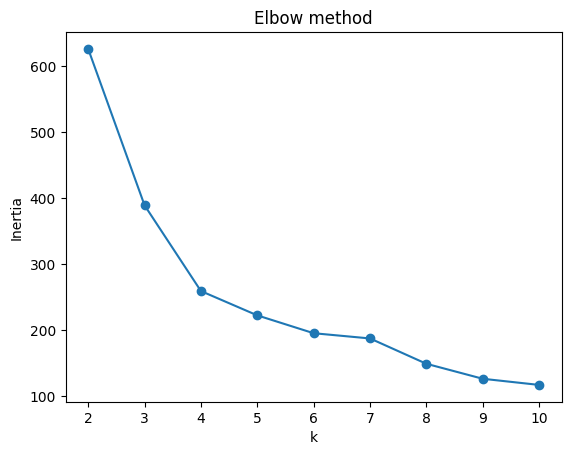

In [7]:
# Evaluate the best cluster number
# Elbow method
import matplotlib.pyplot as plt

plt.plot(cluster_values, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

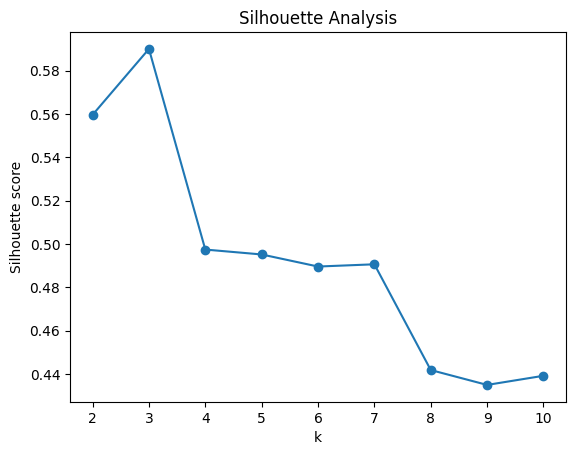

In [8]:
# The higher the score, the better the clustering
plt.plot(cluster_values, silhouette_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette Analysis")
plt.show()

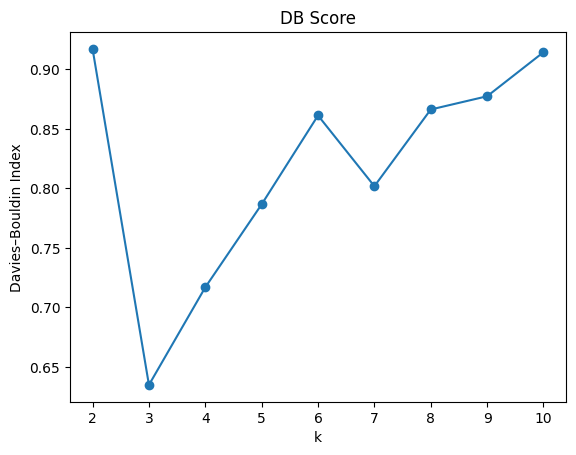

In [9]:
# The lower the score, the better the clustering
plt.plot(cluster_values, davies_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Davies–Bouldin Index")
plt.title("DB Score")
plt.show()

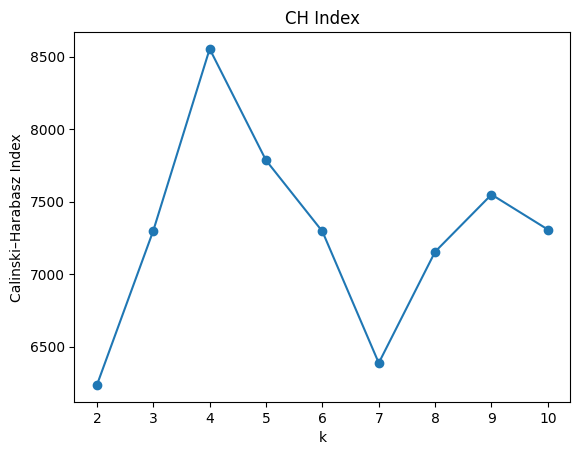

In [10]:
# The higher the score, the better the clustering
plt.plot(cluster_values, calinski_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Calinski–Harabasz Index")
plt.title("CH Index")
plt.show()

# Final Model Definition

In [17]:
# Final model
k = 5
model = KMeans(n_clusters=k, random_state=42)
clusters = model.fit_predict(X)

In [18]:
df["cluster"] = clusters

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X)

# Add the first two principal components as new columns
df["PC1"] = components[:,0]
df["PC2"] = components[:,1]

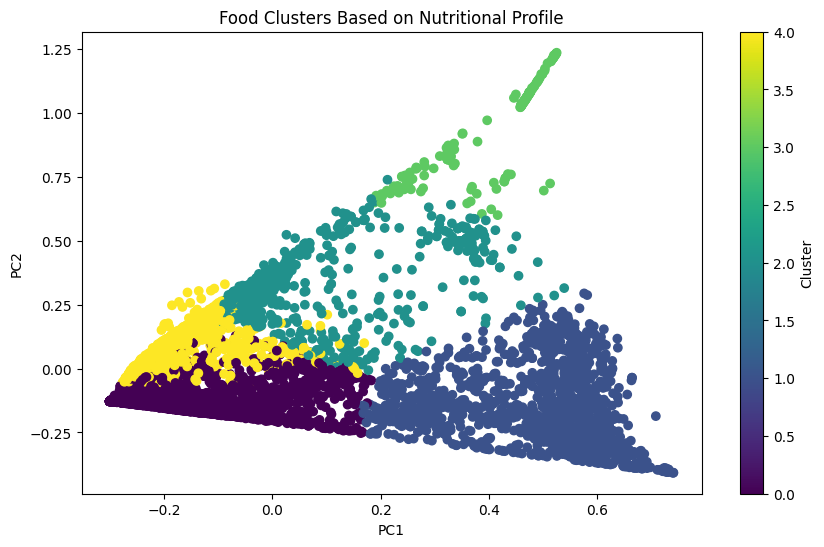

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
scatter = plt.scatter(df["PC1"], df["PC2"],
                      c=df["cluster"], cmap="viridis")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Food Clusters Based on Nutritional Profile")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [21]:
df = df.drop(columns=["PC1", "PC2"])

In [22]:
# Export the model as a pickle file
with open('../models/best_model.pkl', 'wb') as file:
    pickle.dump(model, file)


In [23]:
# Example prediction

# Load the pipeline
with open('../models/best_model.pkl', 'rb') as file:
    model = pickle.load(file)


# Subclustering of clusters 0 and 1

In [24]:
zero_cluster_df = df[df["cluster"] == 0]
X_zero = zero_cluster_df.drop(columns=["food_item", "cluster"])
X_zero.head(10)

,fat_g,satfat_g,carbs_g,protein_g,fiber_g,energy_kcal_calculated
0,0.3800,0.0,28.20000,6.62000,2.700,142.7
6,0.1300,0.0,7.68000,0.89000,1.200,35.4
7,0.2100,0.0,14.80000,0.19000,2.000,61.8
8,0.1000,0.0,14.70000,0.10000,1.700,60.1
9,0.1400,0.0,14.20000,0.27000,2.500,59.1
10,0.1500,0.0,14.80000,0.13000,2.100,61.1
11,0.1600,0.0,15.70000,0.15000,2.100,64.8
76,0.1675,0.0,10.50745,1.14875,1.959,48.1
77,0.1825,0.0,10.48000,1.25000,2.635,48.6
78,0.2338,0.0,3.51495,1.02375,1.259,20.3


In [25]:
one_cluster_df = df[df["cluster"] == 1]
X_one = one_cluster_df.drop(columns=["food_item", "cluster"])
X_one.head(10)

,fat_g,satfat_g,carbs_g,protein_g,fiber_g,energy_kcal_calculated
15,2.4840,0.000,75.018080,8.884920,10.3500,358.0
16,1.9080,0.000,77.161800,8.395200,13.6800,359.4
17,2.4500,0.000,77.398320,8.721680,12.7900,366.5
18,0.4938,0.000,87.312975,0.918225,4.8340,357.4
22,1.0330,0.000,80.313150,7.038850,0.1488,358.7
32,4.6360,0.689,80.450250,5.286750,8.7110,384.7
37,15.2800,13.999,58.902500,16.138500,34.2400,437.7
94,2.4210,0.000,75.881750,11.756250,11.7200,372.3
95,1.7040,0.000,75.669500,12.787500,4.2600,369.2
103,1.6930,0.000,81.305250,7.168750,2.1970,369.1


In [26]:
# Subcluster of cluster 0 KMeans
k = 2
model = KMeans(n_clusters=k, random_state=42)
clusters = model.fit_predict(X_zero)

In [27]:
zero_cluster_df["subcluster"] = clusters
zero_cluster_df.head(10)

/var/folders/78/cqr5rkjj3ql8h1n2wmk7fcnw0000gn/T/ipykernel_40151/1979739869.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zero_cluster_df["subcluster"] = clusters


,food_item,fat_g,satfat_g,carbs_g,protein_g,fiber_g,energy_kcal_calculated,cluster,subcluster
0,"Garlic, raw",0.3800,0.0,28.20000,6.62000,2.700,142.7,0,1
6,"Onions, white, raw",0.1300,0.0,7.68000,0.89000,1.200,35.4,0,0
7,"Apples, red delicious, with skin, raw",0.2100,0.0,14.80000,0.19000,2.000,61.8,0,0
8,"Apples, honeycrisp, with skin, raw",0.1000,0.0,14.70000,0.10000,1.700,60.1,0,0
9,"Apples, granny smith, with skin, raw",0.1400,0.0,14.20000,0.27000,2.500,59.1,0,0
10,"Apples, gala, with skin, raw",0.1500,0.0,14.80000,0.13000,2.100,61.1,0,0
11,"Apples, fuji, with skin, raw",0.1600,0.0,15.70000,0.15000,2.100,64.8,0,0
76,"Squash, winter, butternut, raw",0.1675,0.0,10.50745,1.14875,1.959,48.1,0,0
77,"Squash, winter, acorn, raw",0.1825,0.0,10.48000,1.25000,2.635,48.6,0,0
78,"Cabbage, bok choy, raw",0.2338,0.0,3.51495,1.02375,1.259,20.3,0,0


In [28]:
# Subcluster of cluster 1 KMeans
k = 2
model = KMeans(n_clusters=k, random_state=42)
clusters = model.fit_predict(X_one)

In [29]:
one_cluster_df["subcluster"] = clusters
one_cluster_df.head(10)

/var/folders/78/cqr5rkjj3ql8h1n2wmk7fcnw0000gn/T/ipykernel_40151/1036132310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_cluster_df["subcluster"] = clusters


,food_item,fat_g,satfat_g,carbs_g,protein_g,fiber_g,energy_kcal_calculated,cluster,subcluster
15,"Flour, buckwheat",2.4840,0.000,75.018080,8.884920,10.3500,358.0,1,0
16,"Flour, rye",1.9080,0.000,77.161800,8.395200,13.6800,359.4,1,0
17,"Flour, barley",2.4500,0.000,77.398320,8.721680,12.7900,366.5,1,0
18,"Flour, cassava",0.4938,0.000,87.312975,0.918225,4.8340,357.4,1,0
22,"Rice, white, long grain, unenriched, raw",1.0330,0.000,80.313150,7.038850,0.1488,358.7,1,0
32,"Flour, chestnut",4.6360,0.689,80.450250,5.286750,8.7110,384.7,1,0
37,"Flour, coconut",15.2800,13.999,58.902500,16.138500,34.2400,437.7,1,1
94,"Bulgur, dry, raw",2.4210,0.000,75.881750,11.756250,11.7200,372.3,1,0
95,"Wild rice, dry, raw",1.7040,0.000,75.669500,12.787500,4.2600,369.2,1,0
103,"Fonio, grain, dry, raw",1.6930,0.000,81.305250,7.168750,2.1970,369.1,1,0


In [30]:
# Append dfs: df(without clusters 0 & 1) + df_one + df_zero

# Create the df without clusters 0 and 1
df = df[df["cluster"] != 0]
df = df[df["cluster"] != 1]


df = pd.concat([df, one_cluster_df, zero_cluster_df], axis=0).fillna(0)
df["subcluster"] = df["subcluster"].astype(int)
df.head(10)

,food_item,fat_g,satfat_g,carbs_g,protein_g,fiber_g,energy_kcal_calculated,cluster,subcluster
23,"Beef, ground, 90% lean meat / 10% fat, raw",12.850,5.0510,0.0,18.15625,0.0,188.3,4,0
24,"Beef, ground, 80% lean meat / 20% fat, raw",19.440,6.8450,0.0,17.53125,0.0,245.1,4,0
25,"Pork, ground, raw",17.490,6.2830,0.0,17.80625,0.0,228.6,4,0
26,"Chicken, ground, with additives, raw",7.161,1.5590,0.0,17.91250,0.0,136.1,4,0
27,"Turkey, ground, 93% lean/ 7% fat, raw",9.591,2.2640,0.0,17.34375,0.0,155.7,4,0
52,"Pork, loin, boneless, raw",9.469,3.2850,0.0,21.11875,0.0,169.7,4,0
53,"Pork, loin, tenderloin, boneless, raw",3.899,0.8663,0.0,21.58125,0.0,121.4,4,0
54,"Chicken, breast, boneless, skinless, raw",1.934,0.3488,0.0,22.52500,0.0,107.5,4,0
55,"Chicken, thigh, boneless, skinless, raw",7.916,1.6580,0.0,18.61250,0.0,145.7,4,0
56,"Beef, ribeye, steak, boneless, choice, raw",20.040,7.9660,0.0,18.74375,0.0,255.3,4,0


In [31]:
# Create the supercluster column by joining the cluster and subcluster columns
df["supercluster"] = df["cluster"].astype(str) + "-" + df["subcluster"].astype(str)
df.head(10)

,food_item,fat_g,satfat_g,carbs_g,protein_g,fiber_g,energy_kcal_calculated,cluster,subcluster,supercluster
23,"Beef, ground, 90% lean meat / 10% fat, raw",12.850,5.0510,0.0,18.15625,0.0,188.3,4,0,4-0
24,"Beef, ground, 80% lean meat / 20% fat, raw",19.440,6.8450,0.0,17.53125,0.0,245.1,4,0,4-0
25,"Pork, ground, raw",17.490,6.2830,0.0,17.80625,0.0,228.6,4,0,4-0
26,"Chicken, ground, with additives, raw",7.161,1.5590,0.0,17.91250,0.0,136.1,4,0,4-0
27,"Turkey, ground, 93% lean/ 7% fat, raw",9.591,2.2640,0.0,17.34375,0.0,155.7,4,0,4-0
52,"Pork, loin, boneless, raw",9.469,3.2850,0.0,21.11875,0.0,169.7,4,0,4-0
53,"Pork, loin, tenderloin, boneless, raw",3.899,0.8663,0.0,21.58125,0.0,121.4,4,0,4-0
54,"Chicken, breast, boneless, skinless, raw",1.934,0.3488,0.0,22.52500,0.0,107.5,4,0,4-0
55,"Chicken, thigh, boneless, skinless, raw",7.916,1.6580,0.0,18.61250,0.0,145.7,4,0,4-0
56,"Beef, ribeye, steak, boneless, choice, raw",20.040,7.9660,0.0,18.74375,0.0,255.3,4,0,4-0


In [32]:
df.shape

(7521, 10)